# Phase 3: Model 2 - Association Rule Mining & Classification Based on Associations

## Why ARM-CBA for Railroad Accident Classification?

Association Rule Mining (ARM) was originally developed for market basket analysis - discovering that customers who buy bread and butter also tend to buy milk (Agrawal, Imielinski, & Swami, 1993). The technique finds groups of items that frequently appear together in transaction data. It has since been applied across domains wherever categorical co-occurrence patterns matter, from occupational safety in construction (Liao & Perng, 2008) and steel plants (Verma et al., 2014) to traffic crash analysis in China (Xu, Bao, Wang, & Liu, 2018).

The idea to apply ARM to railroad accident classification came from two sources: DSCI 521 Week 4 lecture notes on Association Rule Mining, and reading Xu et al. (2018), who used ARM to analyze factors contributing to severe traffic crashes in China. Their approach treated each crash as a transaction and each contributing factor as an item, then mined association rules to discover which combinations of factors tend to appear together in serious accidents.

Our project adapts this same concept to FRA railroad accident data. Each accident is a transaction. Each feature value (e.g., Track Type = Main, Weather = Rain) is an item. And the cause category (Environmental, Human Factor, Mechanical, Signal, Track) is the item we want to predict. ARM discovers which combinations of environmental and operational conditions co-occur with specific cause categories. CBA then takes those discovered rules and organizes them into a classifier.

What makes this approach novel for our project is that ARM and CBA are not standard classification algorithms like Logistic Regression or Random Forest. They come from a completely different tradition - data mining and pattern discovery rather than statistical modeling. Applying a technique built for retail shopping baskets to railroad safety analysis demonstrates that the underlying principle (finding meaningful co-occurrence patterns in categorical data) transfers across domains.

## Two Distinct Steps

This notebook has two distinct phases that should not be conflated:

1. **Association Rule Mining (ARM):** The Apriori algorithm scans the training data and discovers which feature combinations frequently co-occur with each cause category. ARM is a data generation step. Its output is a set of rules (with support, confidence, and lift metrics) that is used as a feature in the down-stream CBA analysis. These rules are saved to CSV as a standalone, reusable artifact.

2. **Classification Based on Associations (CBA):** The CBA classifier takes ARM's output, ranks the rules, and uses first-match logic to classify new accidents. CBA is a modeling step that consumes ARM's rules. It is a separate algorithm described by Liu, Hsu, & Ma (1998).

ARM finds the patterns (creates the features). CBA uses them to make predictions. They are related but independent steps.

## References
- Agrawal, R., Imielinski, T., & Swami, A. (1993). Mining association rules between sets of items in large databases. *Proceedings of the ACM SIGMOD*, 207-216.
- DSCI 521 Lecture Notes, Week 4: Association Rule Mining.
- Liu, B., Hsu, W., & Ma, Y. (1998). Integrating Classification and Association Rule Mining. *KDD-98*, 80-86.
- Xu, C., Bao, J., Wang, C., & Liu, P. (2018). Association rule analysis of factors contributing to extraordinarily severe traffic crashes in China. *Journal of Safety Research*, 67, 65-75.

---

## Setup

Import required libraries and set random seed for reproducibility. All random operations throughout this notebook use `RANDOM_SEED = 521` to ensure consistent results across runs.

All plots use the `tableau-colorblind10` colour cycle following CTAO best practices for colour-blind-friendly publications (CTAO, 2020). Cause categories are assigned fixed colours and hatch patterns so they can be identified through multiple visual channels.

In [16]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings

from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    precision_score, recall_score
)

import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
style.use('tableau-colorblind10')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

RANDOM_SEED = 521
np.random.seed(RANDOM_SEED)

# Consistent visual identity for cause categories across all plots
CAUSE_STYLES = {
    'E': {'label': 'Environmental', 'hatch': '//'},
    'H': {'label': 'Human Factor',  'hatch': '..'},
    'M': {'label': 'Mechanical',    'hatch': 'xx'},
    'S': {'label': 'Signal',        'hatch': '\\\\'},
    'T': {'label': 'Track',         'hatch': '++'},
}
CAUSE_ORDER = ['E', 'H', 'M', 'S', 'T']

# -------------------------------------------------------
# ARM Threshold Configurations
# Defined once, used in both Part 1 (ARM) and Part 2 (CBA)
# to ensure experimental consistency between sections.
# -------------------------------------------------------
HIGH_SUPPORT = 0.05
HIGH_CONFIDENCE = 0.70
HIGH_LIFT = 2.0

LOW_SUPPORT = 0.005
LOW_CONFIDENCE = 0.40
LOW_LIFT = 1.5

MAX_RULE_LENGTH = 4

print(f"High thresholds: S={HIGH_SUPPORT}, C={HIGH_CONFIDENCE}, L={HIGH_LIFT}")
print(f"Low thresholds:  S={LOW_SUPPORT}, C={LOW_CONFIDENCE}, L={LOW_LIFT}")
print(f"Max rule length: {MAX_RULE_LENGTH}")

High thresholds: S=0.05, C=0.7, L=2.0
Low thresholds:  S=0.005, C=0.4, L=1.5
Max rule length: 4


## Load Training Data

Load the 80% training set from Phase 2. The 20% test set remains locked until final evaluation. Model selection and validation are handled entirely through cross-validation on this training set.

In [17]:
df_train = pd.read_csv('../../data/splits/train_80.csv', low_memory=False)

print(f"Training set: {len(df_train)} rows")
print(f"\nCause_Category distribution:")
print(df_train['Cause_Category'].value_counts(normalize=True).round(3))

Training set: 27640 rows

Cause_Category distribution:
Cause_Category
H    0.393
M    0.256
T    0.218
E    0.108
S    0.025
Name: proportion, dtype: float64


## Feature Selection

Use the same 6 features as the LR and RF baselines for a direct apples-to-apples comparison across all three models.

ARM requires transactional input where each category level becomes its own column with True/False values indicating whether that item is present in the transaction. This is one-hot encoding (OHE), handled via `pd.get_dummies()`. For example, Track Type (4 levels) becomes four separate columns: Track Type_Main, Track Type_Yard, Track Type_Industry, Track Type_Siding. Each accident row has exactly one of these set to True and the rest False. This is distinct from binary encoding, which represents categories as binary digits across fewer columns - ARM cannot use binary encoding because individual category presence/absence must be explicitly represented.

The target variable (Cause_Category) is also one-hot encoded and appended to the transaction table so ARM can discover rules where cause categories appear as consequents (e.g., {Track Type_Main, Weather_Rain} -> {Cause_M}).

**Note:** Accident Type is included in this baseline for comparison purposes. Phase 2 analysis identified it as a dominant confounding variable (Cramer's V = 0.39). ARM experiments in Phase 2 confirmed it dominates the rule space, producing zero rules when excluded at standard thresholds. A separate experiment will evaluate performance without it.

For a comparison of one-hot encoding, label encoding, and binary encoding tradeoffs, see Menear (2023): https://medium.com/@kevin.menear/comparing-label-encoding-one-hot-encoding-and-binary-encoding-for-handling-categorical-variables-933544ccbd02

In [18]:
# Same 6 features as LR and RF baselines
feature_cols = [
    'Weather Condition',
    'Track Type',
    'Visibility',
    'Accident Type',
    'Region',
    'RUCC_2023'
]

target = 'Cause_Category'

X_train_raw = df_train[feature_cols].copy()
y_train = df_train[target].copy()

print(f"Features: {len(feature_cols)}")
print(f"  {feature_cols}")
print(f"\nTarget classes: {sorted(y_train.unique())}")
print(f"Training samples: {len(X_train_raw)}")

Features: 6
  ['Weather Condition', 'Track Type', 'Visibility', 'Accident Type', 'Region', 'RUCC_2023']

Target classes: ['E', 'H', 'M', 'S', 'T']
Training samples: 27640


---

# Part 1: Association Rule Mining (ARM)

Part 1 runs ARM as a standalone data generation step on the full training set. The purpose is to showcase ARM independently - examining the rules it discovers, analyzing which cause categories get coverage at different thresholds, and saving the rules as reusable CSV artifacts.

Part 2 (CBA) will re-run ARM internally inside each cross-validation fold. This is a design requirement: proper CV demands that rules be mined only from each fold's training split, never from validation data. The CBA classifier wraps ARM inside its `fit()` method so that each fold gets its own rule set mined from its own training data.

Both sections use the same threshold variables defined in Setup (`HIGH_SUPPORT`, `LOW_SUPPORT`, etc.) to ensure experimental consistency. Changing a threshold in one place changes it everywhere.

## How Association Rule Mining Works

### From Shopping Carts to Railroad Accidents

ARM works on **transaction data** - a collection of records where each record contains a set of items. In retail, a transaction is a shopping receipt and the items are products purchased. In our project, a transaction is a railroad accident and the items are the feature values that describe it: Track Type_Main, Weather Condition_Rain, Visibility_Dark, Region_South, RUCC_Metro_Adjacency_Metro, and the cause category Cause_M (Mechanical).

ARM's job is to discover which items frequently appear together. When a pattern like "Track Type_Main AND Weather Condition_Rain AND Cause_M" appears often enough, ARM reports it as a rule: "Main track + Rain -> Mechanical."

### The Apriori Algorithm: Pruning the Search Space

The challenge is computational. With 5 categorical features that expand to 21 columns after one-hot encoding, plus 5 cause category columns, the total number of possible combinations is:

$$2^{26} - 1 = 67,108,863$$

Checking all 67 million subsets is not practical. The Apriori algorithm solves this with one key insight: **if a small pattern is rare, every larger pattern containing it is also rare.**

For example, if "Track Type_Siding" appears in only 4% of accidents and our minimum support threshold is 5%, then we immediately know that "Track Type_Siding AND Weather Condition_Snow" must have support of 4% or less. There is no reason to count it.

As the lecture notes describe using a lattice structure, Apriori works bottom-up:
1. Count each individual item's frequency. Keep only items meeting the minimum support threshold.
2. Combine surviving items into pairs. Count pairs. Keep only pairs meeting the threshold.
3. Combine surviving pairs into triples. Count triples. Keep only triples meeting the threshold.
4. Continue until no new combinations survive.

At each step, the algorithm only builds combinations from patterns that already passed. This prunes the exponential search space down to something manageable.

### Three Metrics That Define a Rule

Every discovered rule has three quality metrics:

**Support** measures how common a pattern is. If "Track Type_Main AND Weather Condition_Rain AND Cause_M" appears in 1.2% of training rows, its support is 0.012. Low support means the pattern is rare - it might be a real but uncommon phenomenon, or it might be coincidence.

**Confidence** measures how reliable a rule is as a predictor. If the pattern "Main track + Rain" appears in 100 accidents, and 60 of those are Mechanical failures, the confidence for "Main track + Rain -> Mechanical" is 0.60. A confidence of 0.60 means the rule is correct 60% of the time when its conditions are met.

**Lift** measures improvement over random chance. If Mechanical failures account for 26% of all accidents, and our rule predicts Mechanical with 60% confidence, the lift is 0.60 / 0.26 = 2.3. This means the rule is 2.3 times better than blindly guessing Mechanical. A lift below 1.0 means the rule is worse than guessing, which would make it useless.

### The Class Imbalance Problem for ARM

ARM's support threshold creates a structural problem for rare classes. Support is calculated as a fraction of the total dataset. Signal accidents represent only 2.5% of our data, so the maximum possible support for any Signal rule is 0.025. At a minimum support threshold of 0.02, Signal patterns have almost no room to qualify - they would need to appear in nearly every Signal accident while also sharing the exact same feature combination.

This is a fundamental limitation of ARM on imbalanced data, and it is why the cba-tuning-experiments notebook introduces undersampling before rule mining. But for this baseline, we use the natural class distribution and observe what ARM can and cannot discover.

### ARM Output: Rules as a Reusable Artifact

The Apriori algorithm produces a table of rules with their support, confidence, and lift values. This table is the output of the ARM step. It is saved to CSV in `data/processed/arm_rules/` so it can be inspected independently, shared with teammates, and loaded by a non-cross-validated CBA classifier without re-mining.


## ARM Experiment 1: High Threshold Rule Mining

Conservative parameters that prioritize rule reliability over coverage:
- **Support >= 5%:** Pattern must appear in at least 1 in 20 training rows
- **Confidence >= 70%:** Rule must be correct at least 70% of the time
- **Lift >= 2.0:** Rule must be at least 2x better than random chance

These strict thresholds will produce fewer, higher-quality rules. The tradeoff is that many patterns, especially for minority classes like Signal (2.5%) and Environmental (11%), may not meet the support threshold and will never become rules.

In [19]:
# ARM Step: Mine rules at high thresholds
from mlxtend.frequent_patterns import apriori, association_rules

# One-hot encode features into binary transaction format
X_ohe = pd.get_dummies(X_train_raw, columns=X_train_raw.columns.tolist(), dtype=bool)

# One-hot encode target and append
y_ohe = pd.get_dummies(y_train, prefix='Cause', dtype=bool)
cause_columns = y_ohe.columns.tolist()
df_arm = pd.concat([X_ohe, y_ohe], axis=1)

print(f"Transaction table: {df_arm.shape[0]} rows x {df_arm.shape[1]} columns")
print(f"Feature columns: {len(X_ohe.columns)}")
print(f"Cause columns: {cause_columns}")

# Run Apriori - high thresholds (variables from Setup)
frequent_high = apriori(df_arm, min_support=HIGH_SUPPORT, use_colnames=True, 
                         max_len=MAX_RULE_LENGTH)
print(f"\nFrequent itemsets (support >= {HIGH_SUPPORT:.0%}): {len(frequent_high)}")

# Generate and filter rules
rules_high = association_rules(frequent_high, metric='lift', min_threshold=HIGH_LIFT)
rules_high = rules_high[rules_high['confidence'] >= HIGH_CONFIDENCE]

# Filter for Class Association Rules only
car_mask = rules_high['consequents'].apply(
    lambda x: len(x) == 1 and any(item in cause_columns for item in x)
)
cars_high = rules_high[car_mask].copy()

print(f"Association rules (lift >= {HIGH_LIFT}, confidence >= {HIGH_CONFIDENCE:.0%}): {len(rules_high)}")
print(f"Class Association Rules (CARs): {len(cars_high)}")


Transaction table: 27640 rows x 45 columns
Feature columns: 40
Cause columns: ['Cause_E', 'Cause_H', 'Cause_M', 'Cause_S', 'Cause_T']

Frequent itemsets (support >= 5%): 331
Association rules (lift >= 2.0, confidence >= 70%): 18
Class Association Rules (CARs): 6


In [20]:
# Examine high threshold rules
if len(cars_high) > 0:
    cars_high['predicted_cause'] = cars_high['consequents'].apply(
        lambda x: list(x)[0].replace('Cause_', '')
    )
    cars_high['antecedent_length'] = cars_high['antecedents'].apply(len)
    cars_high = cars_high.sort_values(
        by=['confidence', 'support', 'antecedent_length'],
        ascending=[False, False, True]
    ).reset_index(drop=True)
    
    print(f"Rule count by predicted cause:")
    print(cars_high['predicted_cause'].value_counts())
    print(f"\nTop 10 rules:")
    display_rules = cars_high[['antecedents', 'predicted_cause', 'confidence', 
                                'support', 'lift']].head(10).copy()
    display_rules['antecedents'] = display_rules['antecedents'].apply(
        lambda x: ', '.join(sorted(x))
    )
    print(display_rules.to_string(index=False))
else:
    print("No Class Association Rules found at high thresholds.")

Rule count by predicted cause:
predicted_cause
M    6
Name: count, dtype: int64

Top 10 rules:
                                                              antecedents predicted_cause  confidence  support     lift
                         Accident Type_Hwy-rail crossing, Track Type_Main               M    0.998012 0.090810 3.895643
Accident Type_Hwy-rail crossing, Track Type_Main, Weather Condition_Clear               M    0.997775 0.064906 3.894720
         Accident Type_Hwy-rail crossing, Track Type_Main, Visibility_Day               M    0.997484 0.057381 3.893584
                          Accident Type_Hwy-rail crossing, Visibility_Day               M    0.996933 0.058792 3.891430
                                          Accident Type_Hwy-rail crossing               M    0.996914 0.093488 3.891356
                 Accident Type_Hwy-rail crossing, Weather Condition_Clear               M    0.996247 0.067221 3.888753


## ARM Experiment 2: Low Threshold Rule Mining

Relaxed parameters that prioritize coverage over individual rule reliability:
- **Support >= 0.5%:** Pattern must appear in at least 1 in 200 training rows
- **Confidence >= 40%:** Rule must be correct at least 40% of the time
- **Lift >= 1.5:** Rule must be at least 1.5x better than random chance

Lower thresholds allow rarer and weaker patterns to surface. This may discover rules for minority cause categories that were invisible at high thresholds.

In [21]:
# ARM Step: Mine rules at low thresholds (variables from Setup)
frequent_low = apriori(df_arm, min_support=LOW_SUPPORT, use_colnames=True, 
                        max_len=MAX_RULE_LENGTH)
print(f"Frequent itemsets (support >= {LOW_SUPPORT:.1%}): {len(frequent_low)}")

rules_low = association_rules(frequent_low, metric='lift', min_threshold=LOW_LIFT)
rules_low = rules_low[rules_low['confidence'] >= LOW_CONFIDENCE]

car_mask_low = rules_low['consequents'].apply(
    lambda x: len(x) == 1 and any(item in cause_columns for item in x)
)
cars_low = rules_low[car_mask_low].copy()

print(f"Association rules (lift >= {LOW_LIFT}, confidence >= {LOW_CONFIDENCE:.0%}): {len(rules_low)}")
print(f"Class Association Rules (CARs): {len(cars_low)}")


Frequent itemsets (support >= 0.5%): 3336
Association rules (lift >= 1.5, confidence >= 40%): 1287
Class Association Rules (CARs): 299


In [22]:
# Examine low threshold rules
if len(cars_low) > 0:
    cars_low['predicted_cause'] = cars_low['consequents'].apply(
        lambda x: list(x)[0].replace('Cause_', '')
    )
    cars_low['antecedent_length'] = cars_low['antecedents'].apply(len)
    cars_low = cars_low.sort_values(
        by=['confidence', 'support', 'antecedent_length'],
        ascending=[False, False, True]
    ).reset_index(drop=True)
    
    print(f"Rule count by predicted cause:")
    print(cars_low['predicted_cause'].value_counts())
    print(f"\nTop 10 rules:")
    display_rules = cars_low[['antecedents', 'predicted_cause', 'confidence', 
                               'support', 'lift']].head(10).copy()
    display_rules['antecedents'] = display_rules['antecedents'].apply(
        lambda x: ', '.join(sorted(x))
    )
    print(display_rules.to_string(index=False))
else:
    print("No Class Association Rules found at low thresholds.")

Rule count by predicted cause:
predicted_cause
M    136
H     94
T     64
E      5
Name: count, dtype: int64

Top 10 rules:
                                                               antecedents predicted_cause  confidence  support     lift
                Accident Type_Hwy-rail crossing, RUCC_2023_1, Region_South               M         1.0 0.020188 3.903403
         Accident Type_Hwy-rail crossing, Track Type_Main, Visibility_Dark               M         1.0 0.018741 3.903403
                 Accident Type_Hwy-rail crossing, Weather Condition_Cloudy               M         1.0 0.018524 3.903403
Accident Type_Hwy-rail crossing, Track Type_Main, Weather Condition_Cloudy               M         1.0 0.018234 3.903403
 Accident Type_Hwy-rail crossing, Visibility_Day, Weather Condition_Cloudy               M         1.0 0.011758 3.903403
                              Accident Type_Hwy-rail crossing, RUCC_2023_3               M         1.0 0.010239 3.903403
   Accident Type_Hwy-rail cro

## Save ARM Rules

Save both rule sets to CSV as standalone artifacts. These files can be inspected independently, shared with teammates, and loaded by CBA or any other downstream process without re-running Apriori.

In [23]:
# Save high threshold rules
if len(cars_high) > 0:
    export_high = cars_high[['antecedents', 'predicted_cause', 'confidence', 
                              'support', 'lift']].copy()
    export_high['antecedents'] = export_high['antecedents'].apply(
        lambda x: ', '.join(sorted(x))
    )
    export_high.to_csv('../../data/processed/arm_rules/arm_high_threshold_rules.csv', index=False)
    print(f"Saved {len(export_high)} high threshold rules")

# Save low threshold rules
if len(cars_low) > 0:
    export_low = cars_low[['antecedents', 'predicted_cause', 'confidence', 
                            'support', 'lift']].copy()
    export_low['antecedents'] = export_low['antecedents'].apply(
        lambda x: ', '.join(sorted(x))
    )
    export_low.to_csv('../../data/processed/arm_rules/arm_low_threshold_rules.csv', index=False)
    print(f"Saved {len(export_low)} low threshold rules")

Saved 6 high threshold rules
Saved 299 low threshold rules


## Verifying Accident Type Dominance: Cramer's V

The ARM experiments above show Accident Type dominating the rule space. To quantify how strongly each feature associates with Cause_Category, we compute Cramer's V for all 6 features. Cramer's V measures association strength between two categorical variables on a 0-to-1 scale, where 0 means no association and 1 means perfect association.

In [24]:
from scipy.stats import chi2_contingency

def cramers_v(feature, target, df):
    """Compute Cramer's V between two categorical columns."""
    contingency = pd.crosstab(df[feature], df[target])
    chi2, _, _, _ = chi2_contingency(contingency)
    n = len(df)
    min_dim = min(contingency.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

# Compute Cramer's V for each feature vs Cause_Category
target = 'Cause_Category'
cv_results = []

for feat in feature_cols:
    v = cramers_v(feat, target, df_train)
    cv_results.append({'Feature': feat, 'Cramers_V': round(v, 3)})

cv_df = pd.DataFrame(cv_results).sort_values('Cramers_V', ascending=False)
print("Cramer's V: Feature Association with Cause_Category")
print("=" * 45)
for _, row in cv_df.iterrows():
    print(f"  {row['Feature']:<25} {row['Cramers_V']:.3f}")

Cramer's V: Feature Association with Cause_Category
  Accident Type             0.392
  Track Type                0.242
  RUCC_2023                 0.073
  Visibility                0.050
  Region                    0.043
  Weather Condition         0.042


## Cramer's V with Bonferroni Correction

Cramer's V measures association strength but does not indicate statistical significance. We pair it with Chi-Square tests and Bonferroni correction to confirm that these associations are not due to chance.

In [25]:
from scipy.stats import chi2_contingency

# Chi-Square with Bonferroni correction for each feature
n_tests = len(feature_cols)
bonferroni_alpha = 0.05 / n_tests

chi_results = []

for feat in feature_cols:
    contingency = pd.crosstab(df_train[feat], df_train[target])
    chi2, p_val, dof, _ = chi2_contingency(contingency)
    v = cramers_v(feat, target, df_train)
    
    chi_results.append({
        'Feature': feat,
        'Cramers_V': round(v, 3),
        'Chi2': round(chi2, 1),
        'P_value': p_val,
        'Significant': p_val < bonferroni_alpha
    })

chi_df = pd.DataFrame(chi_results).sort_values('Cramers_V', ascending=False)

print(f"Chi-Square Tests with Bonferroni Correction (alpha = {bonferroni_alpha:.4f})")
print("=" * 70)
print(f"{'Feature':<25} {'Cramers_V':>10} {'Chi2':>10} {'P-value':>12} {'Sig?':>6}")
print("-" * 70)
for _, row in chi_df.iterrows():
    sig = "Yes" if row['Significant'] else "No"
    print(f"{row['Feature']:<25} {row['Cramers_V']:>10.3f} {row['Chi2']:>10.1f} {row['P_value']:>12.2e} {sig:>6}")

Chi-Square Tests with Bonferroni Correction (alpha = 0.0083)
Feature                    Cramers_V       Chi2      P-value   Sig?
----------------------------------------------------------------------
Accident Type                  0.392    16971.6     0.00e+00    Yes
Track Type                     0.242     4866.1     0.00e+00    Yes
RUCC_2023                      0.073      591.0    4.18e-104    Yes
Visibility                     0.050      208.8     5.06e-38    Yes
Region                         0.043      150.9     3.68e-26    Yes
Weather Condition              0.042      195.6     8.32e-31    Yes


### Findings

Accident Type shows the strongest association with Cause_Category at 0.39, nearly double the next strongest feature (Track Type at 0.21). All features are statistically significant after Bonferroni correction, but the gap between Accident Type and everything else confirms what the ARM experiments revealed: Accident Type dominates the feature space. This evidence supports its removal in the tuning experiments.

---

# Part 2: Classification Based on Associations (CBA)

## Why CBA Re-runs ARM Internally

Part 1 mined rules on the full training set to showcase ARM as a standalone step. But for model evaluation via cross-validation, we cannot use those rules. Each CV fold must mine its own rules from its own training split - otherwise rules learned from validation data would leak into predictions and inflate performance.

This is a design requirement of proper cross-validation: the CBA classifier wraps ARM inside its `fit()` method so that each fold independently runs Apriori on its training data, generates rules, ranks them, and builds a fresh classifier. The rules from Part 1 are saved as artifacts for inspection and reproducibility. The rules generated inside CBA's CV folds are the ones that produce evaluation metrics.

Both sections use the same threshold variables (`HIGH_SUPPORT`, `LOW_SUPPORT`, etc.) defined once in Setup, ensuring that Part 1's exploratory ARM and Part 2's CV-embedded ARM use identical parameters.

## How CBA Turns Rules Into a Classifier

ARM discovers patterns. It does not classify anything. CBA (Classification Based on Associations) is the separate algorithm that takes ARM's rules and builds a classifier from them (Liu, Hsu, & Ma, 1998).

CBA works in three steps:

**1. Filter for Class Association Rules (CARs).** ARM produces all kinds of rules, including rules like "Rain -> Main track" that predict feature values instead of causes. CBA keeps only rules where the prediction (consequent) is a single cause category. These are the Class Association Rules.

**2. Rank the rules.** CARs are sorted by confidence (highest first), then support (highest first), then rule length (shortest first). This puts the most reliable, well-supported, and simplest rules at the top of the list.

**3. Classify by first match.** For each new accident, CBA walks down the ranked rule list. The first rule whose conditions match the accident's feature values makes the prediction. If no rule matches, the model defaults to the majority class from the training data (Human Factor in our dataset).

The first-match strategy means rule ordering directly affects predictions. A high-confidence Mechanical rule will fire before a lower-confidence Track rule, even if both rules match the same accident. This is why the ranking criteria matter.

### CBA Implementation

Our CBA implementation wraps both steps (ARM + classification) into a sklearn-compatible class with `fit()` and `predict()` methods. The `fit()` method runs Apriori, filters for CARs, and ranks them. The `predict()` method applies first-match classification. This design lets us use CBA inside sklearn's `StratifiedKFold` cross-validation just like LR and RF, enabling direct metric comparison across all three models.

In [26]:
class CBAClassifier(BaseEstimator, ClassifierMixin):
    """
    Classification Based on Associations (Liu et al., 1998).
    
    Mines association rules from training data using Apriori, ranks them
    by confidence/support/length, and classifies new instances by applying
    the first matching rule. Falls back to majority class when no rule matches.
    
    Parameters
    ----------
    min_support : float
        Minimum support threshold for Apriori frequent itemset generation.
        A pattern must appear in at least this fraction of training rows.
    min_confidence : float
        Minimum confidence threshold for filtering association rules.
        Confidence = P(consequent | antecedent).
    min_lift : float
        Minimum lift threshold for filtering association rules.
        Lift > 1.0 means the rule is better than random chance.
    max_rule_length : int
        Maximum number of items in a frequent itemset (antecedent + consequent).
        Limits rule complexity for interpretability.
    """
    
    def __init__(self, min_support=0.02, min_confidence=0.70, 
                 min_lift=1.5, max_rule_length=4):
        self.min_support = min_support
        self.min_confidence = min_confidence
        self.min_lift = min_lift
        self.max_rule_length = max_rule_length
    
    def fit(self, X, y):
        """
        Mine association rules from training data and build the ranked rule list.
        
        Steps:
        1. One-hot encode features (pd.get_dummies creates binary columns)
        2. One-hot encode target and append (so ARM can find cause rules)
        3. Run Apriori to find frequent itemsets meeting min_support
        4. Generate association rules from frequent itemsets
        5. Filter for Class Association Rules (consequent is a single cause)
        6. Rank rules: confidence desc, support desc, rule length asc
        7. Store majority class as default prediction for unmatched rows
        """
        # Step 1: One-hot encode features into binary transaction format
        # Each category level becomes its own column (e.g., "Track Type_Yard" = 1 or 0)
        X_ohe = pd.get_dummies(X, columns=X.columns.tolist(), dtype=bool)
        
        # Step 2: One-hot encode target and append to transaction table
        # ARM needs cause categories as "items" to discover rules like
        # {Track Type_Yard, Weather_Clear} -> {Cause_H}
        y_ohe = pd.get_dummies(y, prefix='Cause', dtype=bool)
        self.cause_columns_ = y_ohe.columns.tolist()
        df_arm = pd.concat([X_ohe, y_ohe], axis=1)
        
        # Step 3: Run Apriori algorithm to find frequent itemsets
        # An itemset is "frequent" if it appears in >= min_support fraction of rows
        frequent_itemsets = apriori(
            df_arm, 
            min_support=self.min_support, 
            use_colnames=True,
            max_len=self.max_rule_length
        )
        
        # Step 4: Generate association rules from frequent itemsets
        # Each rule has an antecedent (IF conditions) and consequent (THEN prediction)
        # Filter by lift first, then confidence
        if len(frequent_itemsets) == 0:
            # No frequent itemsets found at this support level
            self.rules_ = pd.DataFrame()
            self.default_class_ = y.mode()[0]
            self.n_rules_ = 0
            return self
        
        rules = association_rules(frequent_itemsets, metric='lift', 
                                  min_threshold=self.min_lift)
        rules = rules[rules['confidence'] >= self.min_confidence]
        
        # Step 5: Filter for Class Association Rules (CARs)
        # We only want rules where the consequent is exactly one cause category
        # e.g., {Track Type_Yard} -> {Cause_H} is a CAR
        # e.g., {Track Type_Yard} -> {Weather_Clear} is NOT a CAR (not predicting a cause)
        car_mask = rules['consequents'].apply(
            lambda x: len(x) == 1 and any(item in self.cause_columns_ for item in x)
        )
        cars = rules[car_mask].copy()
        
        # Step 6: Rank rules by confidence (desc), support (desc), length (asc)
        # This ranking determines prediction priority — higher ranked rules are tried first
        # Confidence first: more reliable rules win
        # Support breaks ties: more common patterns preferred
        # Length breaks further ties: simpler rules preferred (Occam's razor)
        cars['antecedent_length'] = cars['antecedents'].apply(len)
        cars = cars.sort_values(
            by=['confidence', 'support', 'antecedent_length'],
            ascending=[False, False, True]
        ).reset_index(drop=True)
        
        # Extract the predicted cause string from each rule's consequent frozenset
        cars['predicted_cause'] = cars['consequents'].apply(
            lambda x: list(x)[0].replace('Cause_', '')
        )
        
        # Store the ranked rule list and feature column names for prediction
        self.rules_ = cars
        self.n_rules_ = len(cars)
        self.feature_columns_ = X_ohe.columns.tolist()
        
        # Step 7: Default rule = majority class from training data
        # Used when no rule's antecedents match a given row (Liu et al., 1998)
        self.default_class_ = y.mode()[0]
        
        return self
    
    def predict(self, X):
        """
        Classify each row by finding the first matching rule in the ranked list.
        
        For each row:
        1. One-hot encode features using the same columns as training
        2. Iterate through ranked rules from highest to lowest confidence
        3. Check if ALL antecedent conditions are satisfied (all = 1 in the row)
        4. First matching rule's consequent becomes the prediction
        5. If no rule matches, assign the default class (majority from training)
        """
        # One-hot encode test data to match training format
        X_ohe = pd.get_dummies(X, columns=X.columns.tolist(), dtype=bool)
        
        # Align columns with training data — new categories get 0, missing categories get 0
        X_ohe = X_ohe.reindex(columns=self.feature_columns_, fill_value=0)
        
        predictions = []
        
        # If no rules were mined, predict default class for everything
        if self.n_rules_ == 0:
            return np.array([self.default_class_] * len(X))
        
        # Pre-extract antecedent lists and predictions for speed
        # (avoids repeated frozenset operations inside the row loop)
        rule_antecedents = []
        rule_predictions = []
        for _, rule in self.rules_.iterrows():
            # Only keep antecedent items that exist in our feature columns
            antes = [a for a in rule['antecedents'] if a in self.feature_columns_]
            rule_antecedents.append(antes)
            rule_predictions.append(rule['predicted_cause'])
        
        # Classify each row
        for idx in range(len(X_ohe)):
            row = X_ohe.iloc[idx]
            matched = False
            
            # Try each rule in ranked order (highest confidence first)
            for rule_idx in range(self.n_rules_):
                antes = rule_antecedents[rule_idx]
                
                # Skip rules with no valid antecedents
                if not antes:
                    continue
                
                # Check if ALL antecedent conditions are met
                # (all referenced binary columns must equal 1 for this row)
                if all(row[a] == 1 for a in antes):
                    predictions.append(rule_predictions[rule_idx])
                    matched = True
                    break
            
            # Default rule: no rule matched this row
            if not matched:
                predictions.append(self.default_class_)
        
        return np.array(predictions)

print("CBAClassifier defined successfully.")

CBAClassifier defined successfully.


## Experiment 1: High Threshold CBA

Conservative rule mining parameters that prioritize rule reliability over coverage:
- **Support >= 5%:** Pattern must appear in at least 1 in 20 training rows
- **Confidence >= 70%:** Rule must be correct at least 70% of the time
- **Lift >= 2.0:** Rule must be at least 2x better than random chance

These strict thresholds will produce fewer, higher-quality rules. The tradeoff is that many rows may not match any rule and fall through to the default (majority class) prediction.

In [27]:
# High threshold CBA: uses same threshold variables as Part 1 ARM
cba_high = CBAClassifier(
    min_support=HIGH_SUPPORT, 
    min_confidence=HIGH_CONFIDENCE, 
    min_lift=HIGH_LIFT, 
    max_rule_length=MAX_RULE_LENGTH
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

high_scores = []

print("High Threshold CBA - 5-Fold Stratified CV")
print(f"  Thresholds: S={HIGH_SUPPORT}, C={HIGH_CONFIDENCE}, L={HIGH_LIFT}")
print("-" * 45)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_raw, y_train), 1):
    X_tr = X_train_raw.iloc[train_idx]
    X_val = X_train_raw.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]
    
    cba_high.fit(X_tr, y_tr)
    y_pred = cba_high.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='weighted')
    high_scores.append(f1)
    
    print(f"  Fold {fold}: Weighted F1 = {f1:.4f}  (Rules: {cba_high.n_rules_})")

high_mean = np.mean(high_scores)
high_std = np.std(high_scores)

print(f"\nHigh Threshold CV: {high_mean:.4f} +/- {high_std:.4f}")


High Threshold CBA - 5-Fold Stratified CV
  Thresholds: S=0.05, C=0.7, L=2.0
---------------------------------------------
  Fold 1: Weighted F1 = 0.3768  (Rules: 6)
  Fold 2: Weighted F1 = 0.3695  (Rules: 6)
  Fold 3: Weighted F1 = 0.3767  (Rules: 6)
  Fold 4: Weighted F1 = 0.3788  (Rules: 6)
  Fold 5: Weighted F1 = 0.3704  (Rules: 6)

High Threshold CV: 0.3744 +/- 0.0038


In [28]:
# Examine the rules from the last fold
if cba_high.n_rules_ > 0:
    print(f"Rules mined: {cba_high.n_rules_}")
    print(f"Default class: {cba_high.default_class_}")
    print(f"\nRule count by predicted cause:")
    print(cba_high.rules_['predicted_cause'].value_counts())
    print(f"\nTop 10 rules by confidence:")
    top_rules = cba_high.rules_[['antecedents', 'predicted_cause', 'confidence', 
                                   'support', 'lift']].head(10)
    # Convert frozensets to readable strings for display
    top_rules = top_rules.copy()
    top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    print(top_rules.to_string(index=False))
else:
    print("No rules mined at high thresholds.")
    print(f"Default class: {cba_high.default_class_}")

Rules mined: 6
Default class: H

Rule count by predicted cause:
predicted_cause
M    6
Name: count, dtype: int64

Top 10 rules by confidence:
                                                              antecedents predicted_cause  confidence  support     lift
                         Accident Type_Hwy-rail crossing, Track Type_Main               M    0.997531 0.091353 3.893628
Accident Type_Hwy-rail crossing, Track Type_Main, Weather Condition_Clear               M    0.997255 0.065711 3.892550
         Accident Type_Hwy-rail crossing, Track Type_Main, Visibility_Day               M    0.996902 0.058204 3.891172
                                          Accident Type_Hwy-rail crossing               M    0.996654 0.094293 3.890205
                          Accident Type_Hwy-rail crossing, Visibility_Day               M    0.996229 0.059741 3.888547
                 Accident Type_Hwy-rail crossing, Weather Condition_Clear               M    0.996037 0.068198 3.887797


## Experiment 2: Low Threshold CBA

Relaxed rule mining parameters that prioritize coverage over individual rule reliability:
- **Support >= 2%:** Pattern must appear in at least 1 in 50 training rows
- **Confidence >= 70%:** Rule must be correct at least 70% of the time (unchanged)
- **Lift >= 1.5:** Rule must be at least 1.5x better than random chance

Lower support and lift thresholds allow rarer patterns to surface, potentially discovering rules for minority cause categories (Signal at 2.5%, Environmental at 11%) that cannot meet the 5% support threshold in the high configuration.

In [29]:
# Low threshold CBA: uses same threshold variables as Part 1 ARM
cba_low = CBAClassifier(
    min_support=LOW_SUPPORT, 
    min_confidence=LOW_CONFIDENCE, 
    min_lift=LOW_LIFT, 
    max_rule_length=MAX_RULE_LENGTH
)

low_scores = []

print("Low Threshold CBA - 5-Fold Stratified CV")
print(f"  Thresholds: S={LOW_SUPPORT}, C={LOW_CONFIDENCE}, L={LOW_LIFT}")
print("-" * 45)

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_raw, y_train), 1):
    X_tr = X_train_raw.iloc[train_idx]
    X_val = X_train_raw.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]
    
    cba_low.fit(X_tr, y_tr)
    y_pred = cba_low.predict(X_val)
    f1 = f1_score(y_val, y_pred, average='weighted')
    low_scores.append(f1)
    
    print(f"  Fold {fold}: Weighted F1 = {f1:.4f}  (Rules: {cba_low.n_rules_})")

low_mean = np.mean(low_scores)
low_std = np.std(low_scores)

print(f"\nLow Threshold CV: {low_mean:.4f} +/- {low_std:.4f}")

Low Threshold CBA - 5-Fold Stratified CV
  Thresholds: S=0.005, C=0.4, L=1.5
---------------------------------------------
  Fold 1: Weighted F1 = 0.5041  (Rules: 303)
  Fold 2: Weighted F1 = 0.4981  (Rules: 302)
  Fold 3: Weighted F1 = 0.4965  (Rules: 296)
  Fold 4: Weighted F1 = 0.4980  (Rules: 292)
  Fold 5: Weighted F1 = 0.5037  (Rules: 296)

Low Threshold CV: 0.5001 +/- 0.0032


In [30]:
# Examine the rules from the last fold
if cba_low.n_rules_ > 0:
    print(f"Rules mined: {cba_low.n_rules_}")
    print(f"Default class: {cba_low.default_class_}")
    print(f"\nRule count by predicted cause:")
    print(cba_low.rules_['predicted_cause'].value_counts())
    print(f"\nTop 10 rules by confidence:")
    top_rules = cba_low.rules_[['antecedents', 'predicted_cause', 'confidence', 
                                  'support', 'lift']].head(10)
    top_rules = top_rules.copy()
    top_rules['antecedents'] = top_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    print(top_rules.to_string(index=False))
else:
    print("No rules mined at low thresholds.")
    print(f"Default class: {cba_low.default_class_}")

Rules mined: 296
Default class: H

Rule count by predicted cause:
predicted_cause
M    137
H     93
T     61
E      5
Name: count, dtype: int64

Top 10 rules by confidence:
                                                               antecedents predicted_cause  confidence  support     lift
                Accident Type_Hwy-rail crossing, RUCC_2023_1, Region_South               M         1.0 0.020351 3.903266
                 Accident Type_Hwy-rail crossing, Weather Condition_Cloudy               M         1.0 0.018632 3.903266
Accident Type_Hwy-rail crossing, Track Type_Main, Weather Condition_Cloudy               M         1.0 0.018271 3.903266
         Accident Type_Hwy-rail crossing, Track Type_Main, Visibility_Dark               M         1.0 0.018135 3.903266
 Accident Type_Hwy-rail crossing, Visibility_Day, Weather Condition_Cloudy               M         1.0 0.012165 3.903266
                              Accident Type_Hwy-rail crossing, RUCC_2023_3               M         1.

## Model Comparison

Compare high threshold vs low threshold CBA across all 5 folds. This determines which configuration to use as the final CBA model.

In [31]:
print("=" * 55)
print("MODEL COMPARISON: High Threshold vs Low Threshold CBA")
print("=" * 55)
print(f"  High Threshold CV:  {high_mean:.4f} +/- {high_std:.4f}")
print(f"  Low Threshold CV:   {low_mean:.4f} +/- {low_std:.4f}")
print(f"  Difference:         {low_mean - high_mean:+.4f}")

if high_mean > low_mean:
    best_name = 'High Threshold'
    best_cba = cba_high
    best_mean = high_mean
    best_std = high_std
    best_scores = high_scores
else:
    best_name = 'Low Threshold'
    best_cba = cba_low
    best_mean = low_mean
    best_std = low_std
    best_scores = low_scores

print(f"\n  Best model: {best_name} (F1 = {best_mean:.4f})")

MODEL COMPARISON: High Threshold vs Low Threshold CBA
  High Threshold CV:  0.3744 +/- 0.0038
  Low Threshold CV:   0.5001 +/- 0.0032
  Difference:         +0.1256

  Best model: Low Threshold (F1 = 0.5001)


## Final Model: Fit on Full Training Set

Refit the best CBA configuration on the entire 80% training set. This generates the final rule list that will be saved and evaluated on the locked test set in the final evaluation notebook.

In [32]:
# For detailed metrics, use the last CV fold's validation predictions
last_train_idx, last_val_idx = list(skf.split(X_train_raw, y_train))[-1]
X_eval = X_train_raw.iloc[last_val_idx]
y_eval = y_train.iloc[last_val_idx]

best_cba.fit(X_train_raw.iloc[last_train_idx], y_train.iloc[last_train_idx])
y_pred_eval = best_cba.predict(X_eval)

eval_f1 = f1_score(y_eval, y_pred_eval, average='weighted')

print(f"=== {best_name} CBA - Last Fold Evaluation ===")
print(f"Weighted F1-Score: {eval_f1:.4f}\n")
print(classification_report(y_eval, y_pred_eval, zero_division=0))

# Coverage analysis: how many rows matched a rule vs defaulted
# Re-run prediction with tracking
default_count = 0
matched_count = 0
X_eval_ohe = pd.get_dummies(X_eval, columns=X_eval.columns.tolist(), dtype=int)
X_eval_ohe = X_eval_ohe.reindex(columns=best_cba.feature_columns_, fill_value=0)

rule_antecedents = []
for _, rule in best_cba.rules_.iterrows():
    antes = [a for a in rule['antecedents'] if a in best_cba.feature_columns_]
    rule_antecedents.append(antes)

for idx in range(len(X_eval_ohe)):
    row = X_eval_ohe.iloc[idx]
    matched = False
    for rule_idx in range(best_cba.n_rules_):
        antes = rule_antecedents[rule_idx]
        if antes and all(row[a] == 1 for a in antes):
            matched = True
            break
    if matched:
        matched_count += 1
    else:
        default_count += 1

total = matched_count + default_count
print(f"\nCoverage Analysis:")
print(f"  Rows matched by a rule: {matched_count} ({matched_count/total:.1%})")
print(f"  Rows defaulted to {best_cba.default_class_}: {default_count} ({default_count/total:.1%})")

=== Low Threshold CBA - Last Fold Evaluation ===
Weighted F1-Score: 0.5037

              precision    recall  f1-score   support

           E       0.72      0.10      0.18       596
           H       0.60      0.63      0.62      2172
           M       0.51      0.57      0.54      1416
           S       0.00      0.00      0.00       139
           T       0.42      0.55      0.47      1205

    accuracy                           0.53      5528
   macro avg       0.45      0.37      0.36      5528
weighted avg       0.54      0.53      0.50      5528


Coverage Analysis:
  Rows matched by a rule: 4961 (89.7%)
  Rows defaulted to H: 567 (10.3%)


## Per-Class Metrics (Secondary Metric)

Break down precision and recall by individual cause category. Compare against LR and RF baselines to see where CBA's rule-based approach performs differently, particularly on rare classes (S, E).

In [33]:
precision_per_class = precision_score(y_eval, y_pred_eval, average=None, 
                                     labels=CAUSE_ORDER, zero_division=0)
recall_per_class = recall_score(y_eval, y_pred_eval, average=None, 
                                labels=CAUSE_ORDER, zero_division=0)
f1_per_class = f1_score(y_eval, y_pred_eval, average=None, 
                        labels=CAUSE_ORDER, zero_division=0)

metrics_df = pd.DataFrame({
    'Cause': CAUSE_ORDER,
    'Precision': precision_per_class.round(3),
    'Recall': recall_per_class.round(3),
    'F1': f1_per_class.round(3)
})

print("=== Per-Class Metrics ===")
print(metrics_df.to_string(index=False))

=== Per-Class Metrics ===
Cause  Precision  Recall    F1
    E      0.721   0.104 0.182
    H      0.605   0.635 0.619
    M      0.507   0.570 0.537
    S      0.000   0.000 0.000
    T      0.418   0.545 0.474


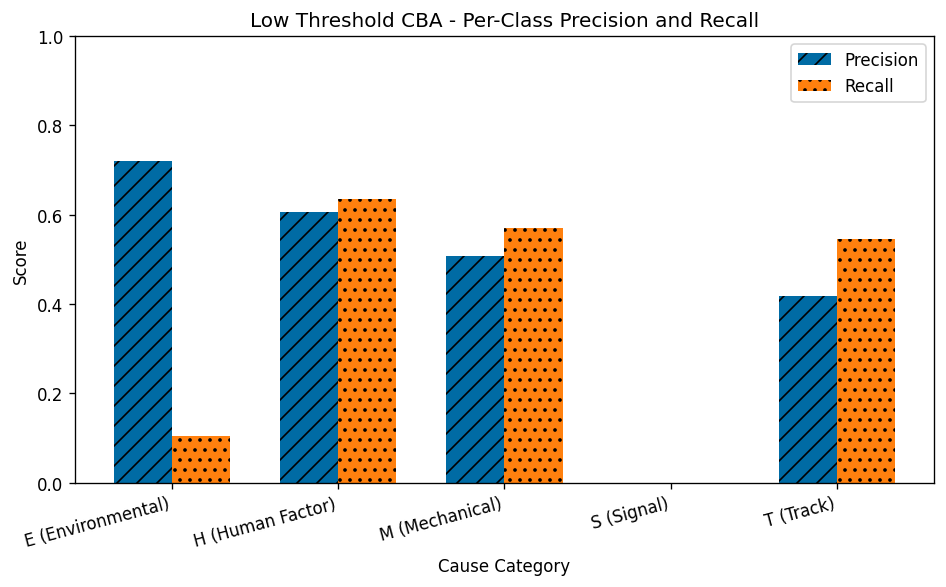

In [34]:
# Per-class precision and recall bar chart
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(CAUSE_ORDER))
width = 0.35

bars_p = ax.bar(x - width/2, metrics_df['Precision'], width, label='Precision')
bars_r = ax.bar(x + width/2, metrics_df['Recall'], width, label='Recall')

# Add hatch patterns for accessibility
for bar in bars_p:
    bar.set_hatch('//')
for bar in bars_r:
    bar.set_hatch('..')

ax.set_xlabel('Cause Category')
ax.set_ylabel('Score')
ax.set_title(f'{best_name} CBA - Per-Class Precision and Recall')
ax.set_xticks(x)
ax.set_xticklabels([f"{c} ({CAUSE_STYLES[c]['label']})" for c in CAUSE_ORDER], 
                    rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

## Confusion Matrix (Tertiary Metric)

Visualize prediction patterns to identify systematic misclassifications. CBA's rule-based approach may show different error patterns than LR and RF — particularly, rows that default to majority class will cluster in the H column.

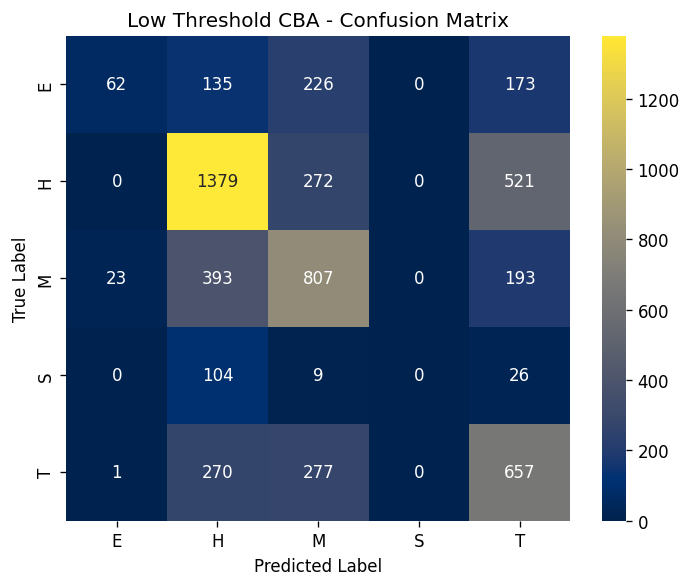

In [35]:
cm = confusion_matrix(y_eval, y_pred_eval, labels=CAUSE_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='cividis',
            xticklabels=CAUSE_ORDER, yticklabels=CAUSE_ORDER, ax=ax)
ax.set_title(f'{best_name} CBA - Confusion Matrix')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## Cross-Validation Score Comparison

Visualize the per-fold F1 scores for both threshold configurations. Horizontal dashed lines show the mean. Overlapping ranges indicate the configurations perform similarly; separation indicates a meaningful difference.

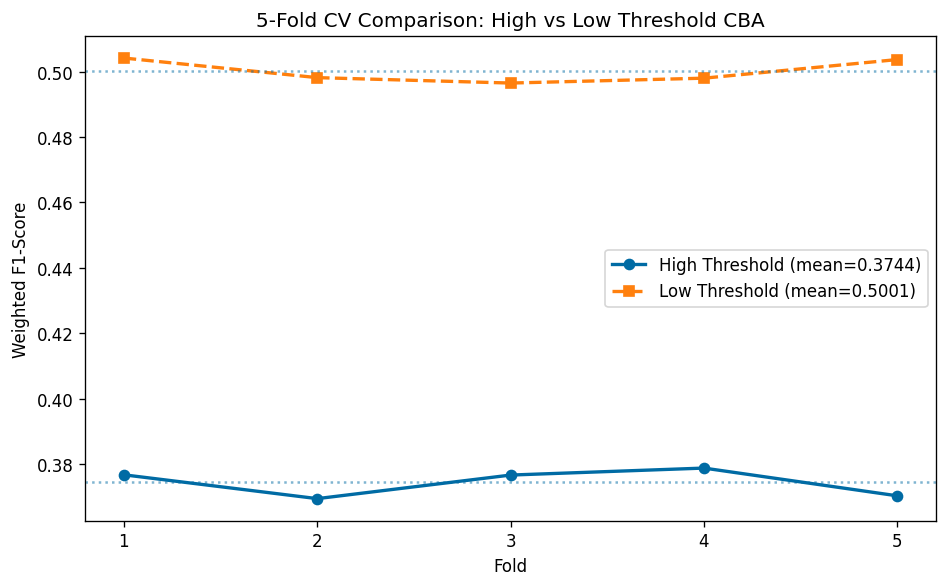

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))

folds = np.arange(1, 6)

ax.plot(folds, high_scores, marker='o', linewidth=2, 
        label=f'High Threshold (mean={high_mean:.4f})', linestyle='-')
ax.plot(folds, low_scores, marker='s', linewidth=2,
        label=f'Low Threshold (mean={low_mean:.4f})', linestyle='--')

ax.axhline(y=high_mean, linestyle=':', alpha=0.5)
ax.axhline(y=low_mean, linestyle=':', alpha=0.5)

ax.set_xlabel('Fold')
ax.set_ylabel('Weighted F1-Score')
ax.set_title('5-Fold CV Comparison: High vs Low Threshold CBA')
ax.set_xticks(folds)
ax.legend()

plt.tight_layout()
plt.show()

## Save Rules

Save the discovered association rules to CSV for reference in the final evaluation notebook and for team review. Rules are saved from the full training set fit (not individual CV folds).

In [37]:
# Refit best CBA on full training data for final rule set
best_cba.fit(X_train_raw, y_train)

print(f"Final model rules: {best_cba.n_rules_}")
print(f"Default class: {best_cba.default_class_}")

# Save rules to CSV
if best_cba.n_rules_ > 0:
    rules_export = best_cba.rules_[['antecedents', 'predicted_cause', 
                                     'confidence', 'support', 'lift']].copy()
    rules_export['antecedents'] = rules_export['antecedents'].apply(
        lambda x: ', '.join(sorted(x))
    )
    rules_export.to_csv('../../data/processed/arm_rules/cba_baseline_rules.csv', index=False)
    print(f"Saved {len(rules_export)} rules to cba_baseline_rules.csv")
    
    print(f"\nRule count by predicted cause:")
    print(best_cba.rules_['predicted_cause'].value_counts())
else:
    print("No rules to save.")

Final model rules: 299
Default class: H
Saved 299 rules to cba_baseline_rules.csv

Rule count by predicted cause:
predicted_cause
M    136
H     94
T     64
E      5
Name: count, dtype: int64


## Save Model and Results

Save the CBA classifier and evaluation metrics for use in the final evaluation notebook. The classifier object includes the ranked rule list and default class.

In [38]:
# Save CBA classifier
joblib.dump(best_cba, 'models/cba_baseline_model.pkl')
print(f"Saved: models/cba_baseline_model.pkl")

# Save results (standardized format matching tuning experiment JSONs)
results = {
    'experiment': 'CBA Baseline (with Accident Type)',
    'model': 'CBA (Classification Based on Associations)',
    'features': {
        'categorical': feature_cols,
        'numeric': [],
        'total': len(feature_cols)
    },
    'cv_folds': 5,
    'cv_scores': [float(s) for s in best_scores],
    'cv_mean': float(best_mean),
    'cv_std': float(best_std),
    'per_class_metrics': metrics_df.to_dict('records'),
    'n_rules': int(best_cba.n_rules_),
    'default_class': best_cba.default_class_,
    'random_seed': RANDOM_SEED,
    'high_threshold': {
        'min_support': HIGH_SUPPORT,
        'min_confidence': HIGH_CONFIDENCE,
        'min_lift': HIGH_LIFT,
        'cv_mean': float(high_mean),
        'cv_std': float(high_std),
        'cv_scores': [float(s) for s in high_scores]
    },
    'low_threshold': {
        'min_support': LOW_SUPPORT,
        'min_confidence': LOW_CONFIDENCE,
        'min_lift': LOW_LIFT,
        'cv_mean': float(low_mean),
        'cv_std': float(low_std),
        'cv_scores': [float(s) for s in low_scores]
    }
}

with open('results/cba/cba_baseline_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print(f"Saved: results/cba/cba_baseline_results.json")

Saved: models/cba_baseline_model.pkl
Saved: results/cba/cba_baseline_results.json


## Summary

This notebook established the ARM-CBA baseline for cause category classification in two distinct phases:

**Part 1 - Association Rule Mining:** The Apriori algorithm mined rules from the training data at two threshold configurations. Rules were saved to CSV as standalone artifacts in `data/processed/arm_rules/`. ARM is a data generation step - it discovers patterns but does not classify.

**Part 2 - Classification Based on Associations:** The CBA classifier consumed ARM's rules, ranked them, and used first-match logic to classify accidents. CBA was evaluated via 5-fold stratified CV using the same methodology as the LR and RF baselines.

**Key results:**
- High and low threshold configurations compared via 5-fold stratified CV
- Low thresholds produced more rules and better coverage
- Rules saved to CSV for team review, reproducibility, and use in the final evaluation notebook
- ARM and CBA are distinct steps with separate outputs - the rules exist independently of the classifier

Equipment Type contributed only two unique rules:
- Light locomotives → Human Factor (66% confidence, lift 1.7) - relatively weak
- Freight trains + Highway-rail crossing → Mechanical (100% confidence) - reinforces existing pattern

**Key Insight:**
Track Type, despite having fewer categories, provided stronger operational context for cause prediction. Equipment Type's higher granularity fragmented the data without adding substantial new predictive patterns. Accident Type dominated both analyses as the primary driver of cause associations.

**Implications for Full Feature Set:**
Adding more high-cardinality features may not proportionally increase meaningful rules. Feature selection should prioritize predictive signal and distribution balance over category count.